#**Data Loading**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn import tree
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import keras.models as km
from keras.models import Sequential
from keras import activations, initializers, regularizers, constraints
from keras.layers import Dense, Activation
df=pd.read_csv('/content/blinkit_new.csv')
df

#**Information Gathering**

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.describe()

In [ ]:
df.count()

#**Data Cleaning**

In [ ]:
df.duplicated().sum()

In [ ]:
df.isnull().sum()

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', palette='viridis', order=df['category'].value_counts().index)
plt.title('Number of Products by Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
df['delivery_status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Delivery Status Distribution')
plt.ylabel('')
plt.show()

In [ ]:
df

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["product_name"] = le.fit_transform(df["product_name"])
df["category"] = le.fit_transform(df["category"])
df["brand"] = le.fit_transform(df["brand"])
df["city"] = le.fit_transform(df["city"])
df["seller"] = le.fit_transform(df["seller"])
df["date_added"] = le.fit_transform(df["date_added"])
df["expiry_date"] = le.fit_transform(df["expiry_date"])
df["delivery_status"] = le.fit_transform(df["delivery_status"])

In [ ]:
X = df[[
    "category",
    "brand",
    "price",
    "rating"
]]

y = df["product_name"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

r2_lr = r2_score(y_test, pred)
print(f"R2 Score: {r2_lr}")

In [ ]:
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)
pred = dt.predict(X_test)
r2_dtr = r2_score(y_test,pred)
print(r2_dtr)

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
pred = rf.predict(X_test)
r2_rfr = r2_score(y_test,pred)
print(r2_rfr)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svr = SVR(kernel="rbf",C=100,gamma="scale")
svr.fit(X_train,y_train)
pred = svr.predict(X_test)
r2_svr = r2_score(y_test,pred)
print("SVR R2 Score:",r2_svr)

In [ ]:
knn = KNeighborsRegressor()
knn.fit(X_train,y_train)
pred = knn.predict(X_test)
r2_knn = r2_score(y_test,pred)
print(r2_knn)

In [ ]:
reg_result = pd.DataFrame({"Model":["Linear Regression","Decision Tree","Random Forest","SVR","KNN"],"R2":[r2_lr,r2_dtr,r2_rfr,r2_svr,r2_knn]})
reg_result.sort_values("R2",ascending=False)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

scores = [0.997835, 0.996865, 0.996532, 0.995647, 0.993345]
models = ["Random Forest", "KNN", "Decision Tree", "SVR", "Linear Regression"]

plot_df = pd.DataFrame({"Model": models, "R2 Score": scores})

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R2 Score", data=plot_df, palette="magma", hue="Model", legend=False)

plt.ylim(0.99, 1.0)
plt.title("Comparison of R2 Scores (Zoomed In)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#**Accuracy**

In [70]:
X = df[[
    "brand",
    "price",
    "discount_pct",
    "final_price",
    "rating",
    "stock",
    "delivery_time_min",
    "city",
    "seller",
    "profit_margin_pct"
]]


y = df["category"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
log = LogisticRegression()
log.fit(X_train,y_train)
pred=log.predict(X_test)
acc_log=accuracy_score(y_test,pred)
print(acc_log)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.0


In [79]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred)
print("DTC: ",acc_dt)

DTC:  0.9753846153846154


In [81]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred)
print("RFC: ",acc_rf)

RFC:  0.9361538461538461


In [84]:
svc=SVC()
svc.fit(X_train,y_train)
pred=svc.predict(X_test)
acc=accuracy_score(y_test,pred)
print("SVC: ",acc)

0.3123076923076923


In [91]:
knn =KNeighborsClassifier()
knn.fit(X_train,y_train)
pred =knn.predict(X_test)
acc_knn=accuracy_score(y_test,pred)
print(acc_knn)

0.2796153846153846


In [95]:
ann = MLPClassifier()
ann.fit(X_train, y_train)
pred = ann.predict(X_test)
acc_ann = accuracy_score(y_test, pred)
print("ANN Accuracy: ", acc_ann)

ANN Accuracy:  0.4023076923076923


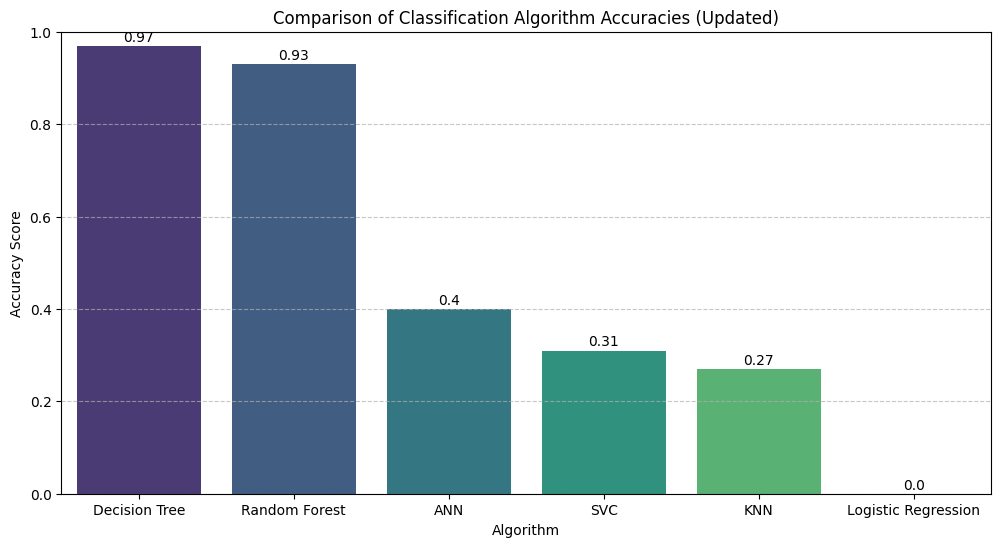

The best algorithm remains Decision Tree with an accuracy of 0.97


In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Using the accuracy values provided: 0.97 (DT), 0.93 (RF), 0.31 (SVC), 0.27 (KNN), 0.40 (ANN)
# We'll keep Logistic Regression at 0.0 as it failed to converge
clf_data = {
    'Algorithm': ['Decision Tree', 'Random Forest', 'ANN', 'SVC', 'KNN', 'Logistic Regression'],
    'Accuracy': [0.97, 0.93, 0.40, 0.31, 0.27, 0.0]
}

comparison_df = pd.DataFrame(clf_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Algorithm', y='Accuracy', data=comparison_df, palette='viridis', hue='Algorithm', legend=False)

plt.title('Comparison of Classification Algorithm Accuracies (Updated)')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotating bars with the values
for index, row in comparison_df.iterrows():
    plt.text(index, row.Accuracy + 0.01, f'{row.Accuracy}', color='black', ha="center")

plt.show()

print(f"The best algorithm remains {comparison_df.iloc[0]['Algorithm']} with an accuracy of {comparison_df.iloc[0]['Accuracy']}")